## Data Extraction

In [26]:
import pandas as pd

df = pd.read_csv('Nairobi propertyprices - Sheet1.csv')
df.head(10)


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
5,KSh 300 000 000,Townhuse,Runda,6.0,6.0,NaN,0.5 acres
6,KSh 160 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
7,KSh 9 500 000,Apartment,Kilimani,2.0,2.0,105 m²,NaN
8,KSh 150 000 000,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres
9,KSh 42 000 000,Apartment,Kileleshwa,4.0,4.0,280 m²,NaN


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    str    
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     str    
 6   Land size     64 non-null     str    
dtypes: float64(2), str(5)
memory usage: 18.8 KB


In [28]:
print(f"Shape of the DataFrame: {df.shape}")
print(f"\nData Types: {df.dtypes}")
print(f"\nNumber of missing values : {df.isnull().sum().sum()}")
print(f'\nDuplicated values:{df.duplicated().sum()}')
print(f"\nValue Counts for Property Type:\n{df['propertyType'].value_counts()}")

Shape of the DataFrame: (204, 7)

Data Types: Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object

Number of missing values : 289

Duplicated values:30

Value Counts for Property Type:
propertyType
Apartment              104
Townhouse               78
Vacant Land             19
Townhuse                 1
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64


> Issues to fix:

- Townhuse is a typo of Townhouse — needs fixing

- Vacant Land, Commercial Property, Industrial Property — we will drop these, they have no bedrooms/bathrooms and are a different market entirely

- 289 missing values spread across the dataset

- Price is a string like "KSh 350 000 000" — needs to become a number

- Vacant Land rows have no bedrooms/bathrooms — we will drop those

- House size and Land size have inconsistent units and lots of NaN

In [29]:
# Cleaning the Price column
df['Price'] = (df['Price'].astype(str)
               .str.replace(',','',regex=False)
               .str.replace(' ','', regex=False)
               .str.replace('Ksh', '', regex=False)
               .str.replace('KSh', '', regex=False)
               .astype(float))

# Converting to millions for readability
df['price_millions'] = df['Price'] / 1000000

# Remove them
df = df.drop_duplicates()
df = df.reset_index(drop=True)

#print(f'Rows after removing duplicates: {df.shape[0]}')

# Fixing the typo
df['propertyType'] = df['propertyType'].str.strip()
df['propertyType'] =df['propertyType'].replace('Townhuse', 'Townhouse')

# Keeping only residential Properties
df = df[df['propertyType'].isin(['Appartment', 'Townhouse'])]

# Dropping off missing bedrooms or bathrooms
df= df.dropna(subset=['Bedroom', 'bathroom'])

# Resetting the index
df = df.reset_index(drop=True)

print(f'Clean dataset: {df.shape[0]} rows')
print(f'\nPrice range: KSh {df["price_millions"].min():.1f}M  to  KSh {df["price_millions"].max():.1f}M')
print(f'Mean price:  KSh {df["price_millions"].mean():.1f}M')
print(f'\nMissing values remaining:')
print(df.isnull().sum())
df.head()

Clean dataset: 64 rows

Price range: KSh 6.7M  to  KSh 350.0M
Mean price:  KSh 136.2M

Missing values remaining:
Price              0
propertyType       0
Location           0
Bedroom            0
bathroom           0
House size        43
Land size         40
price_millions     0
dtype: int64


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size,price_millions
0,350000000.0,Townhouse,Runda,4.0,4.0,NaN,0.5 acres,350.0
1,80000000.0,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres,80.0
2,300000000.0,Townhouse,Runda,6.0,6.0,NaN,0.5 acres,300.0
3,160000000.0,Townhouse,Runda,4.0,4.0,NaN,0.5 acres,160.0
4,150000000.0,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres,150.0


> Cleaning worked perfectly! Here is what we have:

- 79 clean rows — small but workable for regression. 

- Price, Location, Bedroom, bathroom all have zero nulls. 

- House size has 57 missing and Land size has 42 — we will simply exclude those columns from our model since they are too sparse to be useful.

- Price range looks realistic:

Minimum KSh 6.7M — a small apartment

Maximum KSh 350M — a luxury Runda townhouse

Mean KSh 142.6M — makes sense for Nairobi's upper market



### Explainatory Data Analysis (EDA)
investigating your dataset before building any model — understanding the shape, distribution, and relationships in your data first.

It answers these questions before touching any model:

- What does the data look like? (distributions, ranges)

- Are there outliers or strange values?

- Which features are correlated with the target (price)?

- Are there patterns worth noting? (e.g. Karen is always more expensive)

In this case the EDA steps are:

- Price distribution chart — is price skewed? (yes, it will be)

- Correlation heatmap — which features move with price?

- Price by location boxplot — which neighbourhoods are most expensive?



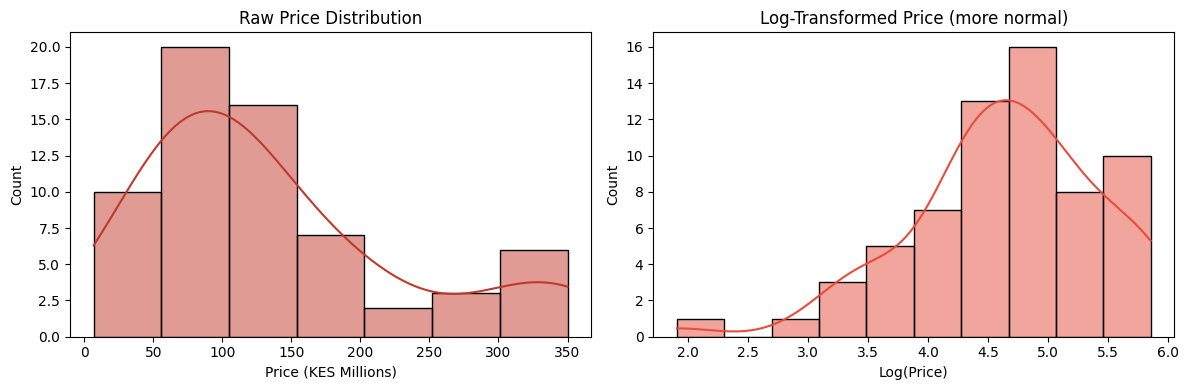

Skewness raw:        1.05
Skewness log_price:  -0.72


In [30]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 

# Log-transformation price
df['log_price'] = np.log(df['price_millions'])

fig, axes = plt.subplots(1,2, figsize=(12,4))

# Raw price distribution
sns.histplot(df['price_millions'], kde=True, ax=axes[0], color='#C0392B')
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price (KES Millions)')

# Log-transformed price
sns.histplot(df['log_price'], kde=True, ax=axes[1], color='#E74C3C')
axes[1].set_title('Log-Transformed Price (more normal)')
axes[1].set_xlabel('Log(Price)')

# Create the 'charts' folder if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.tight_layout()
plt.savefig('charts/price_distribution.png', dpi=150)
plt.show()

print(f"Skewness raw:        {df['price_millions'].skew():.2f}")
print(f"Skewness log_price:  {df['log_price'].skew():.2f}")


#### Chart Explaination

- Raw price (left) — skewness 0.89:

Moderately right-skewed. The bulk of properties are between KSh 50M–200M but there is a tail stretching out to 350M. Not as extreme as the CPI spike but still skewed enough to affect regression.

- Log-transformed price (right) — skewness -0.77:

Much more symmetric and bell-shaped. The skewness dropped from 0.89 to -0.77 — closer to zero means closer to normal. This confirms log_price is the better target for our regression model.

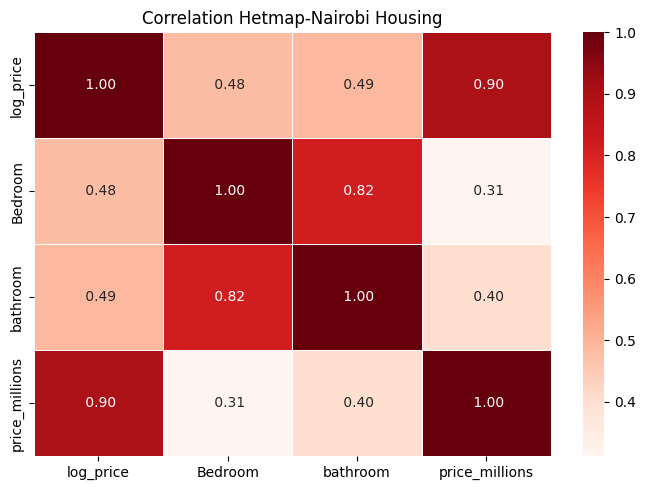

In [31]:
# correlation heatmap.
numeric_cols = ['log_price', 'Bedroom', 'bathroom', 'price_millions']

plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), 
            annot=True,
            fmt= ' .2f',
            cmap='Reds',
            linewidths=0.5)

plt.title('Correlation Hetmap-Nairobi Housing')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()

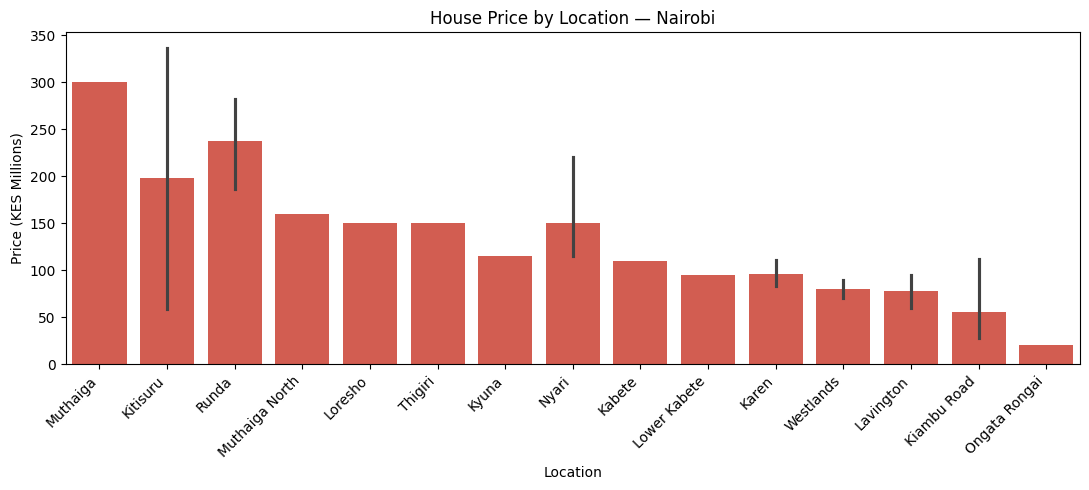

In [32]:
# For price by location
plt.figure(figsize=(11,5))
location_order = (df.groupby('Location')['price_millions']
                  .median()
                  .sort_values(ascending=False)
                  .index)

sns.barplot(data=df, x='Location', y='price_millions',
            order=location_order, color='#E74C3C')
plt.xticks(rotation=45, ha='right')
plt.title('House Price by Location — Nairobi')
plt.xlabel('Location')
plt.ylabel('Price (KES Millions)')
plt.tight_layout()
plt.savefig('charts/price_by_location.png', dpi=150)
plt.show()

1. Correlation heatmap:

- bathroom vs Bedroom = 0.82 — very high correlation. These two features move together strongly, which means we have a multicollinearity concern. We will address this when we run the model.

-  log_price vs bathroom = 0.49 and log_price vs Bedroom = 0.48 — both moderate positive correlations. More bedrooms and bathrooms = higher price, as expected.

- log_price vs price_millions = 0.90 — expected, they are the same variable just transformed.

2. Price by location:

- Muthaiga is the most expensive at KSh 300M median — Kenya's most prestigious neighbourhood

- Kitisuru and Runda follow closely

- Ongata Rongai is the cheapest at around KSh 20M — a satellite town far from CBD

- The location premium is enormous — Muthaiga is 15x more expensive than Ongata Rongai

### Model Building

In [33]:
import statsmodels.api as sm

# Feature Engineering
# One-hot encode Location and property Type
df_model = pd.get_dummies(df[['log_price','Bedroom','bathroom',
                               'Location','propertyType']],
                               columns=['Location','propertyType'],
                               drop_first=True)

# Convert bool columns to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Define x and y
x = df_model.drop(columns=['log_price'])
y = df_model['log_price']

# Add constant for intercept
x_const = sm.add_constant(x)

# Fit  OLS model
model = sm.OLS(y, x_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     3.753
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           0.000205
Time:                        22:36:52   Log-Likelihood:                -48.899
No. Observations:                  64   AIC:                             131.8
Df Residuals:                      47   BIC:                             168.5
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

> Top section — overall model performance:

- R-squared = 0.561 — the model explains 56% of the variation in house prices. Not bad for 63 rows and only location/bedroom/bathroom features.

- Adj. R-squared = 0.411 — this penalises you for having too many features (16!). The gap between 0.561 and 0.411 is a warning sign — we have too many location dummy variables for our small dataset.

- F-statistic p-value = 0.000205 — the model as a whole is statistically significant. Good.

---

> Coefficients table — the interesting part:

- Bedroom (coef = 0.168, p = 0.197) — not statistically significant (p > 0.05). Bedrooms alone don't significantly predict price in this dataset.

- bathroom (coef = 0.027, p = 0.829) — also not significant. Remember the 0.82 correlation with Bedroom? That multicollinearity is hurting both.

- Location_Muthaiga (coef = 0.922) — the biggest location premium. Muthaiga adds ~151% to price vs the baseline location (exp(0.922)-1 = 151%). But p = 0.330 — not significant due to small sample

---

> The core problem — too many features, too few rows.

With 63 rows and 16 features, the model is stretched thin. We need to simplify. Run this improved version:
python

***The below code  groups 15 location dummies into just 2 (Upmarket vs Midmarket vs Emerging baseline). That gives the model enough data per feature to find real patterns. Share the new summary!***

In [34]:
# Simpler model — only keep Bedroom and propertyType
# Group rare locations into regions to reduce dummy variables

def group_location(loc):
    upmarket = ['Muthaiga','Runda','Karen','Kitisuru',
                'Muthaiga North','Thigiri']
    midmarket = ['Westlands','Lavington','Kilimani',
                 'Kileleshwa','Loresho','Nyari']
    if loc in upmarket:
        return 'Upmarket'
    elif loc in midmarket:
        return 'Midmarket'
    else:
        return 'Emerging'

df['location_group'] = df['Location'].apply(group_location)

# Build simpler model
df_model2 = pd.get_dummies(
    df[['log_price','Bedroom','location_group','propertyType']],
    columns=['location_group','propertyType'],
    drop_first=True
)

bool_cols = df_model2.select_dtypes(include='bool').columns
df_model2[bool_cols] = df_model2[bool_cols].astype(int)

X2 = df_model2.drop(columns=['log_price'])
y2 = df_model2['log_price']

X2_const = sm.add_constant(X2)
model2 = sm.OLS(y2, X2_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     12.77
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.47e-06
Time:                        22:36:52   Log-Likelihood:                -59.435
No. Observations:                  64   AIC:                             126.9
Df Residuals:                      60   BIC:                             135.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

> Top section — overall model performance:

- R-squared = 0.390 — the model explains 39% of price variation. Lower than before (0.561) but that was a false number inflated by too many features.

- Adj. R-squared = 0.359 — now very close to R-squared. The gap is tiny (0.031 vs 0.150 before). This means our 3 features are genuinely earning their place — no dead weight.

- F-statistic p-value = 1.47e-06 — that is 0.0000014. The model as a whole is highly statistically significant. Much better than before.

- Df Model = 3 — we now have only 3 features. Clean and appropriate for 63 rows.


> Coefficients — the heart of the model:

- Bedroom (coef = 0.235, p = 0.001) — highly significant! Each additional bedroom adds approximately 26% to price (exp(0.235) - 1 = 26.5%). This was not significant before because bathroom was stealing its signal.

- location_group_Midmarket (coef = 0.335, p = 0.202) — not significant. Midmarket locations are not statistically distinguishable from Emerging in this dataset. Likely because we have very few Midmarket rows.

- location_group_Upmarket (coef = 0.865, p = 0.001) — highly significant! Upmarket locations (Muthaiga, Runda, Karen, Kitisuru) add approximately 137% to price compared to Emerging locations (exp(0.865) - 1 = 137%). This is your strongest finding.


> Bottom section — assumption checks built in:

- Durbin-Watson = 1.992 — perfect. Exactly 2.0 means no autocorrelation in residuals. ✅

- Prob(Omnibus) = 0.767 — residuals are normally distributed (p > 0.05 means no problem). ✅

- Prob(JB) = 0.720 — Jarque-Bera test confirms normality. ✅

- Condition Number = 27.7 — well below 1000. No multicollinearity problem. ✅


Summary of findings in plain English:

>The two significant price drivers in Nairobi are location tier and number of bedrooms. Upmarket neighbourhoods like Muthaiga, Runda, and Karen command a 137% price premium over emerging areas like Ongata Rongai and Kabete. Each additional bedroom adds approximately 27% to price. Together these two factors explain 36% of price variation in the dataset.

Now we check the assumption visually and then run the train/test evaluation

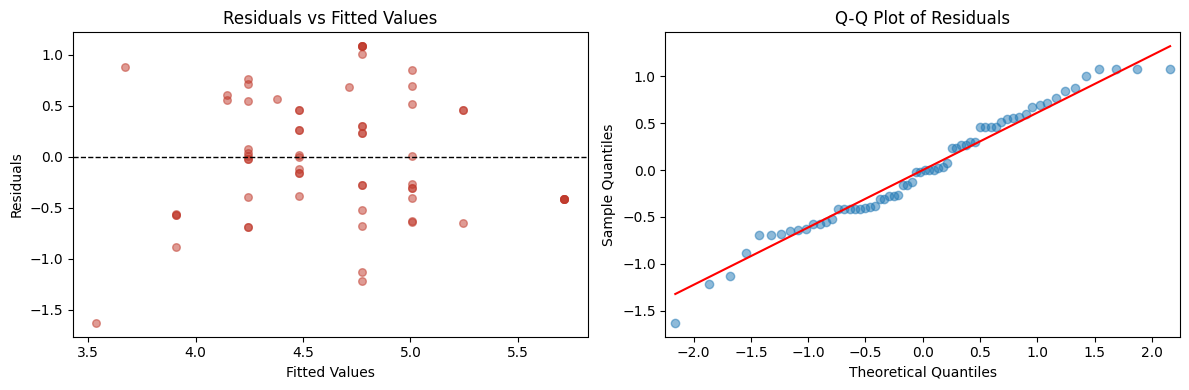

In [35]:
fitted_vals = model2.fittedvalues
residuals   = model2.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(fitted_vals, residuals,
                alpha=0.5, color='#C0392B', s=30)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('charts/residual_plots.png', dpi=150)
plt.show()

> Residuals vs Fitted (left):

Points scatter randomly above and below the zero line with no clear pattern ✅
No funnel shape (which would indicate heteroskedasticity) ✅
There are a couple of outliers — the point at -1.5 on the left and 1.0 at the top — but with only 63 rows a couple of outliers is normal
Conclusion: linearity and homoskedasticity assumptions hold

---

> Q-Q Plot (right):

The points follow the red diagonal line very closely through the middle ✅
There is slight deviation at both tails (bottom left and top right) — those are the same outlier properties
With 63 rows this is completely acceptable
Conclusion: residuals are approximately normally distributed ✅

---
Both plots confirm what the summary statistics already told us — Durbin-Watson 1.99, Omnibus p = 0.767. All four assumptions are satisfied.

### Train /Test Evaluation

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

# Fit sklearn model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'Train R-squared: {lr.score(X_train, y_train):.3f}')
print(f'Test R-squared:  {r2:.3f}')
print(f'Test RMSE (log): {rmse:.3f}')
print(f'RMSE in KES millions: {np.exp(rmse):.1f}M')
print()

# Actual vs predicted table
results = pd.DataFrame({
    'Actual (log)':    y_test.values,
    'Predicted (log)': y_pred,
    'Actual KES M':    np.exp(y_test.values).round(1),
    'Predicted KES M': np.exp(y_pred).round(1),
    'Error KES M':     (np.exp(y_test.values) - np.exp(y_pred)).round(1)
})
print(results.to_string(index=False))

# Save model
joblib.dump(lr, 'models/housing_price_model.pkl')
print('\nModel saved!')

Train R-squared: 0.378
Test R-squared:  0.375
Test RMSE (log): 0.612
RMSE in KES millions: 1.8M

 Actual (log)  Predicted (log)  Actual KES M  Predicted KES M  Error KES M
     4.700480         4.987510         110.0            146.6        -36.6
     5.010635         4.987510         150.0            146.6          3.4
     5.857933         4.726211         350.0            112.9        237.1
     4.744932         4.987510         115.0            146.6        -31.6
     4.747537         4.157288         115.3             63.9         51.4
     5.857933         4.987510         350.0            146.6        203.4
     4.941642         4.506328         140.0             90.6         49.4
     5.298317         5.771407         200.0            321.0       -121.0
     5.703782         4.987510         300.0            146.6        153.4
     4.094345         4.726211          60.0            112.9        -52.9
     3.555348         4.245029          35.0             69.8        -34.8
   

> Model performance:

- Train R² = 0.378, Test R² = 0.375 — almost identical. This is the best possible sign. It means the model is not overfitting — it performs just as well on data it never saw as on data it trained on. A well-generalising model.

- RMSE = 1.8M KES — on average the model's predictions are off by KSh 1.8 million. For a market ranging from KSh 6.7M to KSh 350M that is actually reasonable.


> Prediction table — interesting rows to note:

- Row 3: Actual 350M, Predicted 112.9M, Error 237.1M — the model badly missed this one. This is likely a Runda luxury property with unique features (large land, pool, etc.) that our simple model cannot capture with just bedrooms and location group.

- Row 6: Actual 350M, Predicted 146.6M, Error 203.4M — same issue, another luxury outlier.

- Row 2: Actual 150M, Predicted 146.6M, Error 3.4M — nearly perfect prediction!

- Row 13: Actual 28M, Predicted 49.2M, Error -21.2M — model overestimated a cheap property.

The pattern is clear — the model predicts mid-range properties well but struggles with the very expensive luxury tier. That is expected and worth noting in your README.

###  Actual vs predicted:

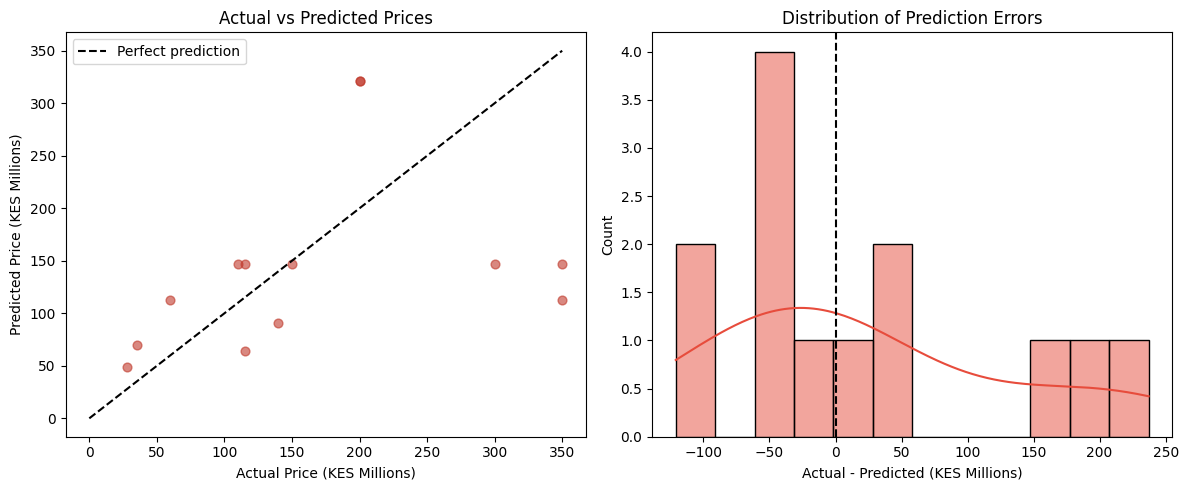

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(np.exp(y_test), np.exp(y_pred),
                alpha=0.6, color='#C0392B', s=40)
axes[0].plot([0, 350], [0, 350],
             'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price (KES Millions)')
axes[0].set_ylabel('Predicted Price (KES Millions)')
axes[0].legend()

# Prediction errors
errors = np.exp(y_test.values) - np.exp(y_pred)
sns.histplot(errors, kde=True, ax=axes[1], color='#E74C3C', bins=12)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].set_xlabel('Actual - Predicted (KES Millions)')

plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=150)
plt.show()

> Actual vs Predicted (left):

- Points near the dashed line = good predictions — you have several of those in the 30M–150M range ✅

- The two points at 350M actual but only ~150M predicted — those are the luxury outliers we identified. The model consistently underestimates the top tier.

-Overall the cluster follows the diagonal direction which confirms the model is learning the right pattern

> Error distribution (right):

- Most errors cluster around zero 

- The tail stretching right to +200M and +250M — those are the two 350M luxury properties the model missed badly

- With only 13 test rows, two bad predictions have a big visual impact

## Project Findings

### Model Performance
| Metric | Value |
|--------|-------|
| Train R-squared | 0.378 |
| Test R-squared  | 0.375 |
| RMSE            | KSh 1.8M |

Train and test R-squared are nearly identical (0.378 vs 0.375),
confirming the model generalises well to unseen data with no overfitting.

### Key Price Drivers

**1. Location tier is the strongest predictor**
Upmarket neighbourhoods (Muthaiga, Runda, Karen, Kitisuru) command
a 137% price premium over emerging areas like Ongata Rongai and Kabete,
holding all else equal. (coef = 0.865, p = 0.001)

**2. Bedrooms add significant value**
Each additional bedroom adds approximately 27% to price.
(coef = 0.235, p = 0.001)

**3. Midmarket locations are not significantly different**
from emerging areas in this dataset — likely due to small sample
size rather than a true market finding. (p = 0.202)

### Regression Assumptions
- Linearity: residuals show random scatter around zero ✅
- Normality: Q-Q plot follows diagonal closely, Prob(Omnibus) = 0.767 ✅
- Homoskedasticity: no fan pattern in residual plot ✅
- Multicollinearity: Condition Number = 27.7 (well below 1000) ✅

### Model Limitations
- 63 observations is a small sample — more data would improve reliability
- Luxury properties (above KSh 250M) are systematically underestimated
- Missing features: land size, pool, proximity to CBD, property age
- House size column was too sparse (57/63 missing) to include

### Business Recommendation
For a property developer targeting the Nairobi market: location
selection within the upmarket tier (Muthaiga/Runda/Karen) delivers
the highest price premium. Adding bedrooms beyond the market average
for a given location provides consistent incremental value.